In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

In [2]:
data = sns.load_dataset('tips')

In [3]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
data.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [10]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


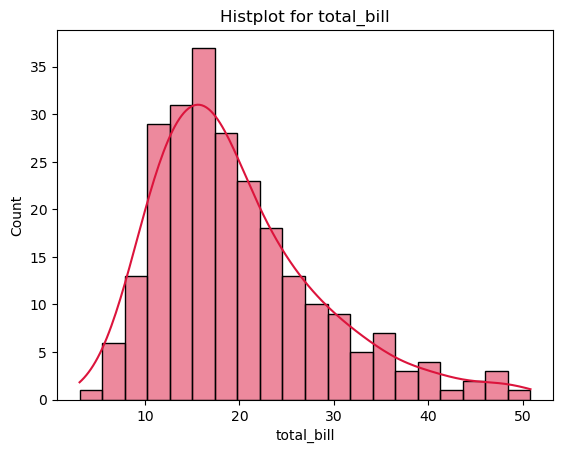

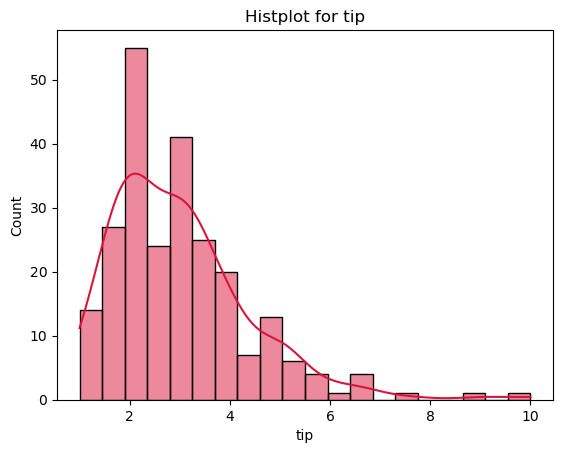

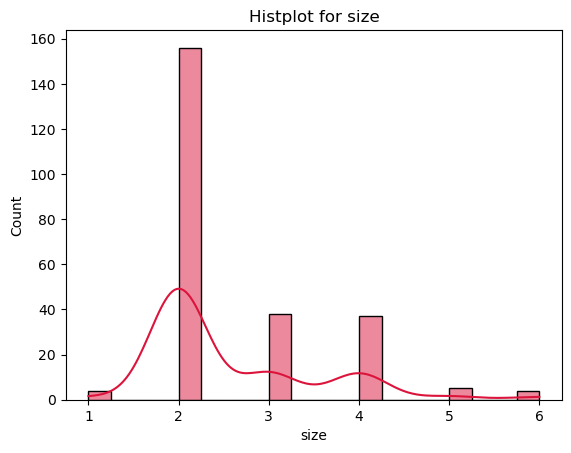

In [20]:
def num_cols(df,col):
    plt.title(f"Histplot for {col}")
    sns.histplot(df[col],color='crimson',bins=20,kde=True)
    plt.show()
    
numerical_columns = ['total_bill','tip','size']
for cols in numerical_columns:
    num_cols(data, cols)

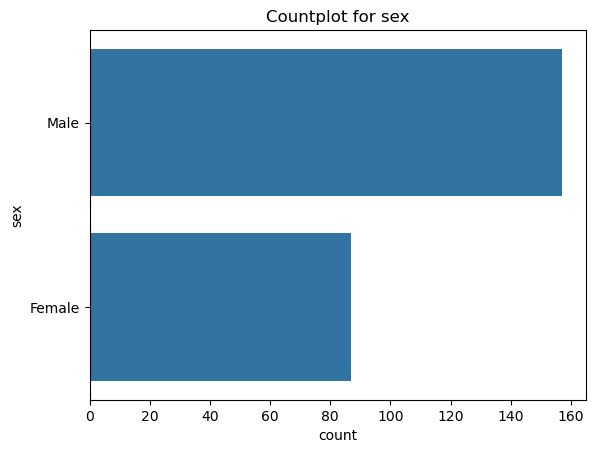

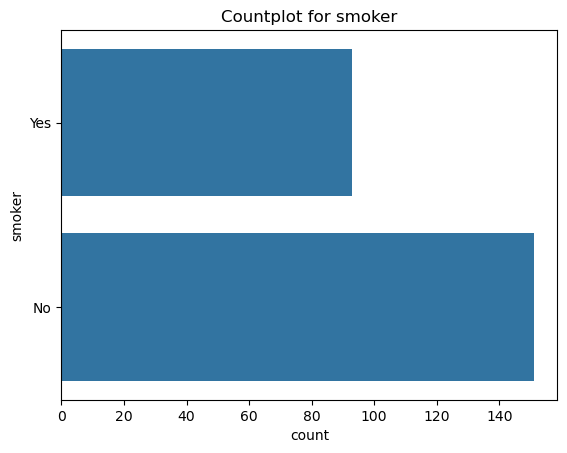

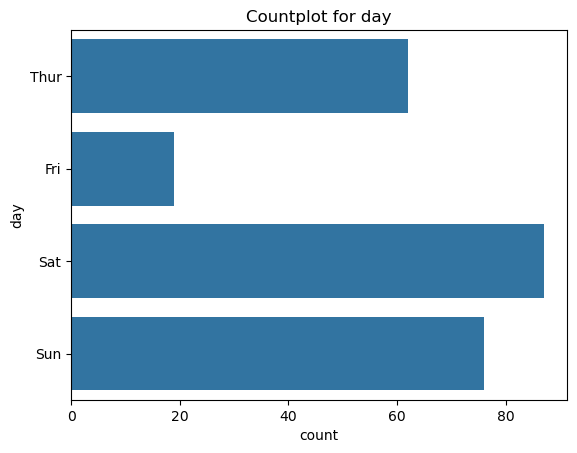

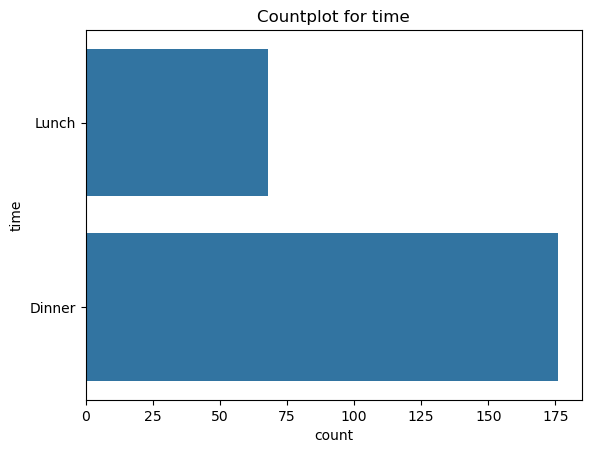

In [33]:
def cat_cols(df,col):
    plt.title(f"Countplot for {col}")
    sns.countplot(df[col])
    plt.show()
    
Categorical_columns = ['sex','smoker','day','time']
for cols in Categorical_columns:
    cat_cols(data, cols)

In [38]:
from sklearn.model_selection import train_test_split #Split the data 

tips_encoded = pd.get_dummies(data,drop_first=True)

X = tips_encoded.drop('tip',axis=1)
y = tips_encoded['tip']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [41]:
from sklearn.linear_model import LinearRegression #Choose model 
clf = LinearRegression()
clf.fit(X_train,y_train)

LinearRegression()

In [50]:
from sklearn.metrics import r2_score, mean_squared_error #Model Evaluation
y_pred = clf.predict(X_test)

In [51]:
r2_score(y_pred, y_test)

0.38869499071494007

In [52]:
mean_squared_error(y_pred,y_test)

0.7033566017436103

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), 
                    param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [55]:
 grid.best_params_

{'max_depth': 5, 'n_estimators': 100}

In [56]:
 grid.best_score_

0.3772785857488656